In [ ]:
#Import librairies
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [ ]:
#Connect to drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Extract columns names from the adult.names file
cols = []
with open('/content/drive/MyDrive/dataprocessingmethod/adult_dataset/adult.names', 'r') as f:
  for line in f:
    match = re.match(r'(?P<colname>[a-z\-]+):.', line)
    if match:
      cols.append(match.group('colname'))
#target column
cols.append('income')

#Load the adult.data (training set)
adult_train = pd.read_csv('/content/drive/MyDrive/dataprocessingmethod/adult_dataset/adult.data', names=cols, header=None, skipinitialspace=True)

#Load the adult.test (testing set)
adult_test = pd.read_csv('/content/drive/MyDrive/dataprocessingmethod/adult_dataset/adult.test', names=cols, header=None, skipinitialspace=True, skiprows=1)

#Cleaning testing set: remove "." in the expected values columns
adult_test['income'] = adult_test['income'].str.rstrip('.')

#Key attributes/features in the dataset.
print(adult_train.info())
print(adult_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov  

In [ ]:
#Summary statistics (e.g., number of rows, columns, missing values)
#Replace '?' by NaN (missing values)
adult_train = adult_train.replace('?', pd.NA)
adult_test = adult_test.replace('?', pd.NA)

print("(number of rows, number of columns): ",adult_train.shape)
print("Number of missing values in the training set: ",adult_train.isna().sum().sum())
print("Data types:", adult_train.dtypes)
print("Descriptive statictics for numerical columns:\n", adult_train.describe())

(number of rows, number of columns):  (32561, 15)
Number of missing values in the training set:  4262
Data types: age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object
Descriptive statictics for numerical columns:
                 age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000  

**PREPROCESSING**

In [ ]:
#Select numeric columns and categorical columns
numeric_cols = adult_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = adult_train.select_dtypes(include=['object']).columns

#Exclude income column if present
if 'income' in numeric_cols:
  numeric_cols = numeric_cols.drop('income')
if 'income' in categorical_cols:
  categorical_cols = categorical_cols.drop('income')

1. Data Cleaning

In [ ]:
#Check if there is duplicates entries
num_duplicates = adult_train.duplicated().sum()
print("Number of duplicate rows in the dataset:", num_duplicates)

#remove duplicates
adult_train = adult_train.drop_duplicates()

#Check if the duplicates were removed
num_duplicates = adult_train.duplicated().sum()
print("Number of duplicate rows in the dataset:", num_duplicates)

Number of duplicate rows in the dataset: 24
Number of duplicate rows in the dataset: 0


In [ ]:
#Check number of rows after removing duplicates data
print(adult_train.shape)

(32537, 15)


In [ ]:
#Check the missing valiues
adult_train.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
#Handle the outliers, missing values + standardization (scaling)
def winsorize_array(X, limits=(0.01,0.01)):
  # Convert to NumPy array
  X = np.array(X)
  X_wins = np.empty_like(X)
  for i in range(X.shape[1]):
    X_wins[:,i] = winsorize(X[:,i], limits=limits)
  return X_wins

log_transformer = FunctionTransformer(np.log1p, validate=True)

#Columns with outliers
outliers_cols = ['fnlwgt', 'capital-gain', 'capital-loss']

#Pipeline for outliers
outlier_pipeline = Pipeline(steps=[
    ('winsorize', FunctionTransformer(winsorize_array, kw_args={'limits': (0.01,0.01)})),
    ('log', log_transformer)
])

#Pipeline for categorical columns
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#Handle outliers & encoding categorical pipeline
preprocessor_initial = ColumnTransformer(transformers=[
    ('outliers', outlier_pipeline, outliers_cols),
    ('pass_numeric', 'passthrough', [col for col in numeric_cols if col not in outliers_cols]),
    ('categorical', categorical_pipeline, categorical_cols)
])

#Convert pd.NA to np.nan for simpleimputer
adult_train = adult_train.fillna(np.nan)
adult_test = adult_test.fillna(np.nan)

#preprocessor initial + scaling
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_initial),
    ('scaler', StandardScaler())
])

#Apply pipeline
X_train_processed = full_pipeline.fit_transform(adult_train)
X_test_processed = full_pipeline.transform(adult_test)

#Check statistics
#Scaling
print("Mean after standardisation:", X_train_processed.mean(axis=0).round(2))
print("Standart deviation after standardisation:", X_train_processed.std(axis=0).round(2))

Mean after standardisation: [-0. -0.  0. -0. -0.  0. -0.  0. -0.  0. -0. -0. -0.  0. -0.  0.  0. -0.
  0. -0. -0. -0. -0. -0.  0.  0. -0. -0. -0.  0. -0. -0.  0.  0.  0.  0.
 -0. -0. -0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0.  0.  0.  0. -0.  0.
 -0.  0.  0. -0.  0.  0.  0. -0.  0. -0.  0.  0. -0.  0.  0.  0.  0.  0.
  0. -0. -0.  0. -0.  0. -0.  0. -0. -0. -0. -0. -0. -0.  0. -0. -0. -0.
 -0.  0.  0. -0. -0. -0.  0.  0.  0.  0. -0.  0. -0. -0.  0.]
Standart deviation after standardisation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**EDA**

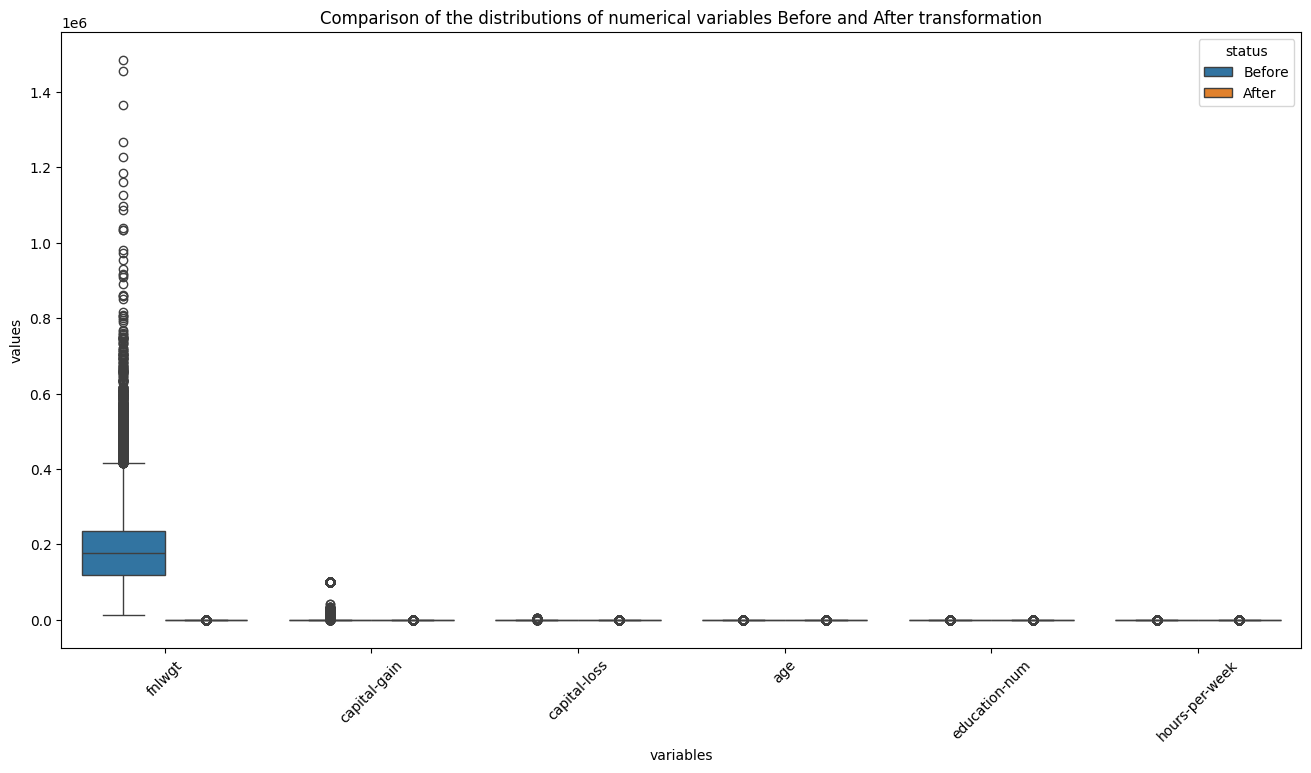

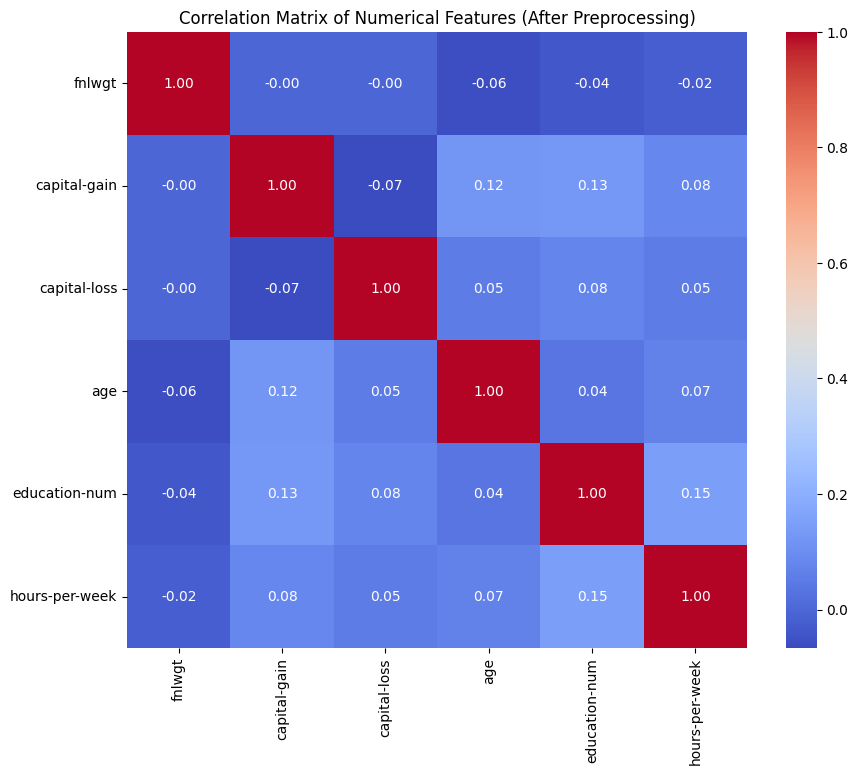

In [ ]:
#check if outliers have been handled
# Index of columns in X_train_processed
n_outliers = len(outliers_cols)
n_pass_numeric = len([col for col in numeric_cols if col not in outliers_cols])

# create DataFrame for new numerical columns
# Extraire colonnes transformées correspondant aux numériques
X_numeric_processed = np.hstack([
    #outliers
    X_train_processed[:, :n_outliers],
    #others
    X_train_processed[:, n_outliers:n_outliers + n_pass_numeric],
])

X_numeric_test_processed = np.hstack([
    X_test_processed[:, :n_outliers],
    X_test_processed[:, n_outliers:n_outliers + n_pass_numeric],
])

#outliers_cols + others num cols
numeric_cols_ordered = outliers_cols + [col for col in numeric_cols if col not in outliers_cols]

# DataFrame with raw data
df_before = adult_train[numeric_cols_ordered].copy()
df_corr_ready = pd.DataFrame(X_numeric_processed, columns=numeric_cols_ordered)
df_before = df_before.melt(var_name='variables', value_name='values')
df_before['status'] = 'Before'

# DataFrame after preprocessing
df_after = pd.DataFrame(X_numeric_processed, columns=numeric_cols_ordered)
df_after = df_after.melt(var_name='variables', value_name='values')
df_after['status'] = 'After'

# Combine both DataFrame
df_compare = pd.concat([df_before, df_after], ignore_index=True)

# Visualization
plt.figure(figsize=(16, 8))
sns.boxplot(x='variables', y='values', hue='status', data=df_compare)
plt.title('Comparison of the distributions of numerical variables Before and After transformation')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df_corr_ready.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features (After Preprocessing)")
plt.show()

In [ ]:
# Colonnes numériques, d'abord les outliers puis les autres
numeric_passthrough = [col for col in numeric_cols if col not in outliers_cols]
numeric_cols_ordered = outliers_cols + numeric_passthrough

# Colonnes catégorielles one-hot encodées (ordre du pipeline)
categorical_features = (
    full_pipeline.named_steps['preprocessor']
    .named_transformers_['categorical']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols)
)

# Fusion de tous les noms dans le bon ordre pour DataFrame
all_columns = numeric_cols_ordered + list(categorical_features)

In [ ]:
#Check if missing values have been handled
if np.isnan(X_train_processed).sum() == 0:
    print("No missing values")
else:
    print("There are missing values.")


No missing values


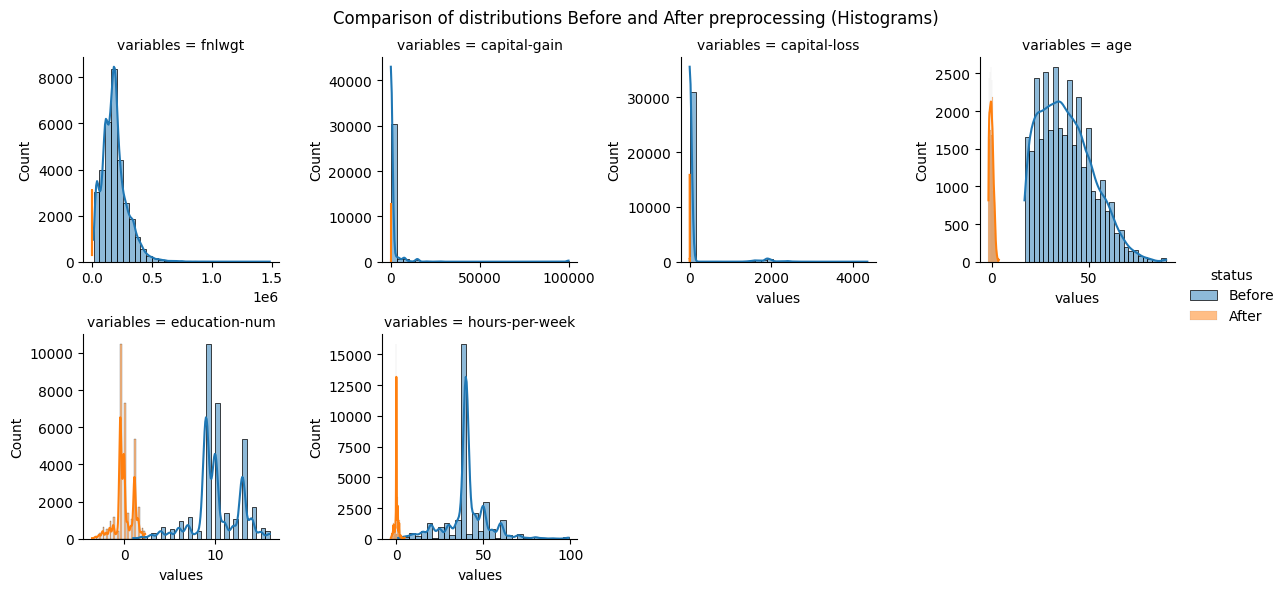

In [ ]:
# Histogrammes comparés avant/après pour chaque variable numérique
g = sns.FacetGrid(df_compare, col="variables", hue="status", col_wrap=4, sharex=False, sharey=False, height=3)
g.map(sns.histplot, "values", bins=30, kde=True, alpha=0.5).add_legend()

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Comparison of distributions Before and After preprocessing (Histograms)')
plt.show()

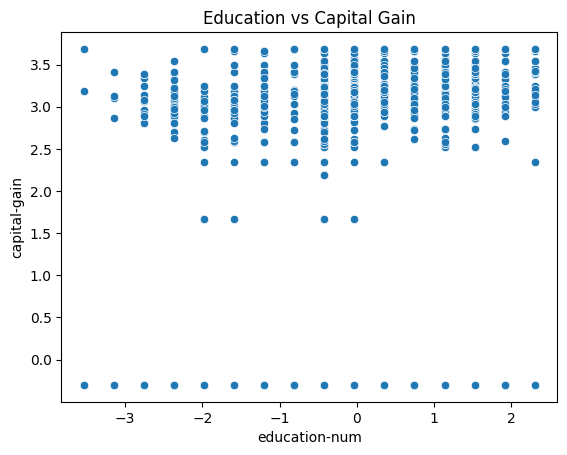

In [ ]:
# DataFrame after preprocessing
df_after_notmelted = pd.DataFrame(X_numeric_processed, columns=numeric_cols_ordered)
sns.scatterplot(data=df_after_notmelted, x='education-num', y='capital-gain')
plt.title("Education vs Capital Gain")
plt.show()

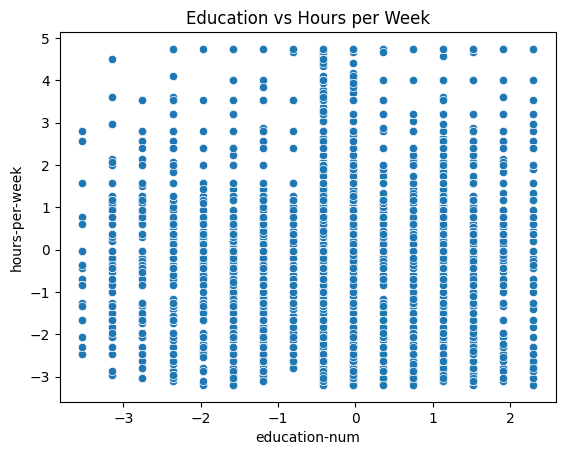

In [ ]:
sns.scatterplot(data=df_after_notmelted, x='education-num', y='hours-per-week')
plt.title("Education vs Hours per Week")
plt.show()


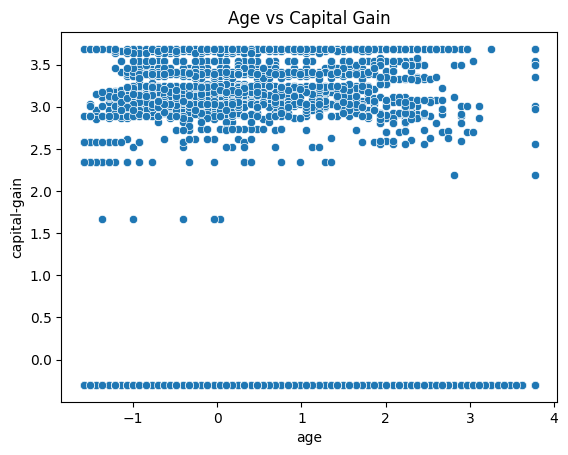

In [ ]:
sns.scatterplot(data=df_after_notmelted, x='age', y='capital-gain')
plt.title("Age vs Capital Gain")
plt.show()

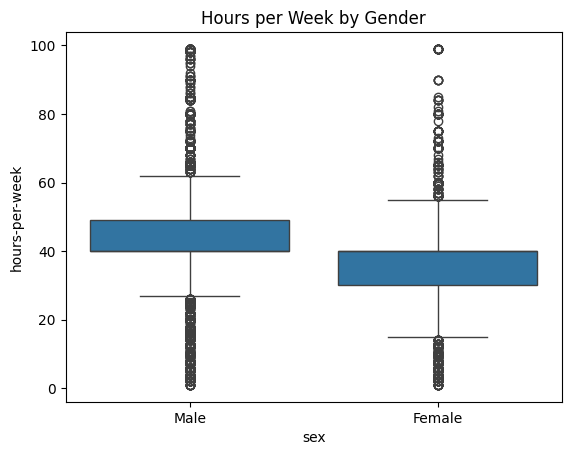

In [ ]:
sns.boxplot(data=adult_train, x='sex', y='hours-per-week')
plt.title("Hours per Week by Gender")
plt.show()

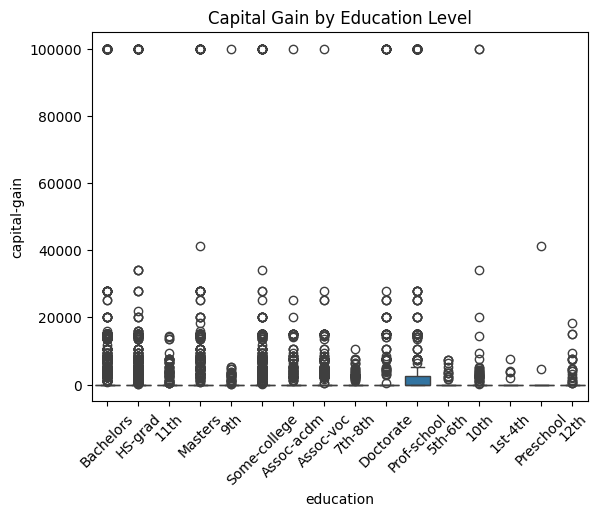

In [ ]:
sns.boxplot(data=adult_train, x='education', y='capital-gain')
plt.xticks(rotation=45)
plt.title("Capital Gain by Education Level")
plt.show()

In [ ]:
df_processed = pd.DataFrame(X_train_processed, columns=all_columns)
print(df_processed)

df_test_processed = pd.DataFrame(X_test_processed, columns=all_columns)

         fnlwgt  capital-gain  capital-loss       age  education-num  \
0     -1.164901      2.884863      -0.22119  0.030390       1.134777   
1     -1.049051     -0.300272      -0.22119  0.836973       1.134777   
2      0.479191     -0.300272      -0.22119 -0.042936      -0.420679   
3      0.615390     -0.300272      -0.22119  1.056950      -1.198407   
4      1.203285     -0.300272      -0.22119 -0.776193       1.134777   
...         ...           ...           ...       ...            ...   
32532  0.762988     -0.300272      -0.22119 -0.849519       0.745913   
32533 -0.057928     -0.300272      -0.22119  0.103716      -0.420679   
32534 -0.083783     -0.300272      -0.22119  1.423579      -0.420679   
32535  0.370086     -0.300272      -0.22119 -1.216148      -0.420679   
32536  0.943694      3.685910      -0.22119  0.983625      -0.420679   

       hours-per-week  workclass_Federal-gov  workclass_Local-gov  \
0           -0.035664              -0.174361            -0.262201 

In [ ]:
#Income tranformation into binary value
y_train = adult_train['income'].replace({'<=50K': 0, '>50K': 1}).values
y_test = adult_test['income'].replace({'<=50K': 0, '>50K': 1}).values


#working on df as numpy
X_train = df_processed.values
X_test = df_test_processed.values

#LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

/tmp/ipython-input-72-556495238.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = adult_train['income'].replace({'<=50K': 0, '>50K': 1}).values
/tmp/ipython-input-72-556495238.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = adult_test['income'].replace({'<=50K': 0, '>50K': 1}).values


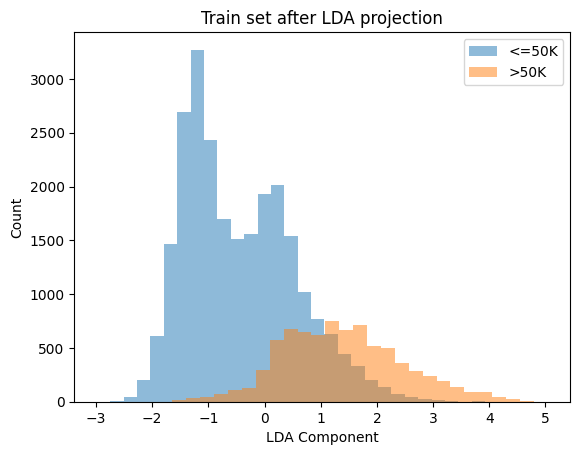

In [ ]:
#Visualization
plt.hist(X_train_lda[y_train == 0], bins=30, alpha=0.5, label='<=50K')
plt.hist(X_train_lda[y_train == 1], bins=30, alpha=0.5, label='>50K')
plt.xlabel('LDA Component')
plt.ylabel('Count')
plt.legend()
plt.title('Train set after LDA projection')
plt.show()


In [ ]:
# Logistic Regression
param_dist_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [100, 300, 500]
}

logreg = LogisticRegression(class_weight='balanced', random_state=42)

# SVC
param_dist_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svc = SVC(class_weight='balanced', random_state=42)

# Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Logistic Regression
search_logreg = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_dist_logreg,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
search_logreg.fit(X_train_lda, y_train)
best_logreg = search_logreg.best_estimator_

# SVC
search_svc = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_dist_svc,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
search_svc.fit(X_train_lda, y_train)
best_svc = search_svc.best_estimator_

# Random Forest
search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
search_rf.fit(X_train_lda, y_train)
best_rf = search_rf.best_estimator_

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 6.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver(se

In [ ]:
#Test
y_pred_logreg = best_logreg.predict(X_test_lda)
y_pred_svc = best_svc.predict(X_test_lda)
y_pred_rf = best_rf.predict(X_test_lda)

#Accuracy
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

#Precision
precision_logreg = precision_score(y_test, y_pred_logreg)
precision_svc = precision_score(y_test, y_pred_svc)
precision_rf = precision_score(y_test, y_pred_rf)

#Recall
recall_logreg = recall_score(y_test, y_pred_logreg)
recall_svc = recall_score(y_test, y_pred_svc)
recall_rf = recall_score(y_test, y_pred_rf)

#F1-Score
f1_logreg = f1_score(y_test, y_pred_logreg)
f1_svc = f1_score(y_test, y_pred_svc)
f1_rf = f1_score(y_test, y_pred_rf)

#Confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression:")
print("Accuracy:", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall:", recall_logreg)
print("F1-Score:", f1_logreg)
print("Confusion Matrix:\n", cm_logreg)

print("\nSupport Vector Classifier:")
print("Accuracy:", accuracy_svc)
print("Precision:", precision_svc)
print("Recall:", recall_svc)
print("F1-Score:", f1_svc)
print("Confusion Matrix:\n", cm_svc)

print("\nRandom Forest:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)
print("Confusion Matrix:\n", cm_rf)

Logistic Regression:
Accuracy: 0.8076285240464345
Precision: 0.5656974604343026
Recall: 0.7992719708788352
F1-Score: 0.6625
Confusion Matrix:
 [[10075  2360]
 [  772  3074]]

Support Vector Classifier:
Accuracy: 0.8434985565997175
Precision: 0.7139090309822017
Recall: 0.5631825273010921
F1-Score: 0.6296511627906977
Confusion Matrix:
 [[11567   868]
 [ 1680  2166]]

Random Forest:
Accuracy: 0.7989067010625883
Precision: 0.5672624647224835
Recall: 0.6271450858034321
F1-Score: 0.5957026426278094
Confusion Matrix:
 [[10595  1840]
 [ 1434  2412]]


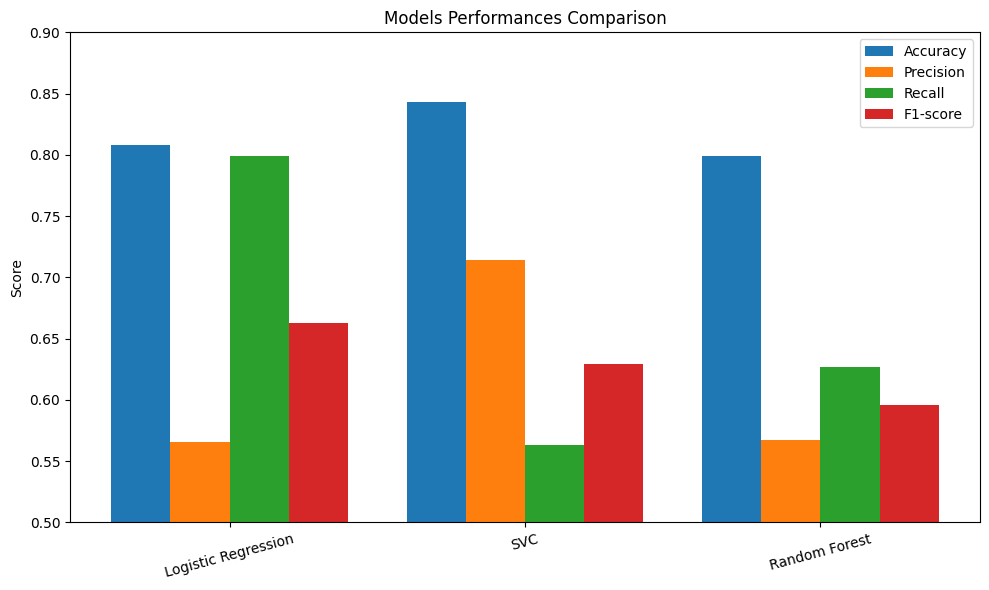

In [ ]:
#Visualization
# Nom des modèles
models = ['Logistic Regression', 'SVC', 'Random Forest']

# Valeurs des métriques
all_accuracy = [accuracy_logreg, accuracy_svc, accuracy_rf]
all_precision = [precision_logreg, precision_svc, precision_rf]
all_recall = [recall_logreg, recall_svc, recall_rf]
all_f1_score = [f1_logreg, f1_svc, f1_rf]

# Création du bar plot groupé
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - 1.5*width, all_accuracy, width, label='Accuracy')
ax.bar(x - 0.5*width, all_precision, width, label='Precision')
ax.bar(x + 0.5*width, all_recall, width, label='Recall')
ax.bar(x + 1.5*width, all_f1_score, width, label='F1-score')

ax.set_ylabel('Score')
ax.set_title('Models Performances Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0.5, 0.9)

plt.tight_layout()
plt.show()

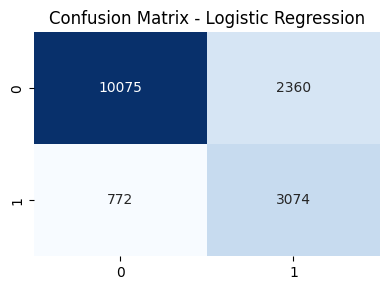

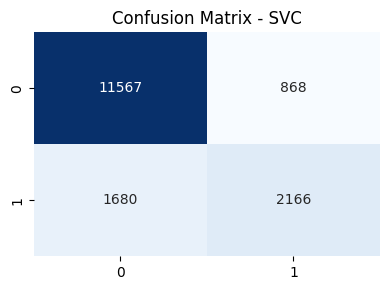

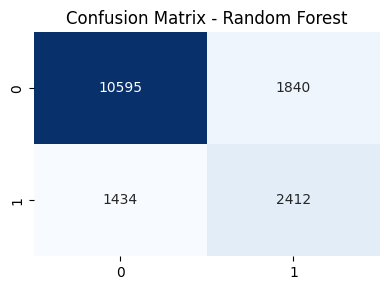

In [ ]:
# Fonction utilitaire pour afficher une heatmap joliment
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Affichage des 3 matrices
plot_confusion_matrix(cm_logreg, "Confusion Matrix - Logistic Regression")
plot_confusion_matrix(cm_svc, "Confusion Matrix - SVC")
plot_confusion_matrix(cm_rf, "Confusion Matrix - Random Forest")